In [ ]:
import dataclasses
import importlib.util
import inspect
import os
import re
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

REQUIRED = ["trl>=0.12", "transformers>=4.45", "accelerate", "datasets", "peft", "scikit-learn"]

def ensure_deps():
    """Install in ONE pip call so the resolver picks a mutually compatible set."""
    try:
        import trl
        import transformers
        return False
    except ImportError:
        print("Installing dependencies...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", *REQUIRED])
        return True

def drop_broken_torchao():
    """Colab ships torchao 0.10.0; peft demands >0.16 and raises rather than skipping.

    Nothing here uses torchao, so removing it is safer than upgrading (an upgrade can
    drag in a torch build that does not match this runtime)."""
    if importlib.util.find_spec("torchao") is None:
        return False
    try:
        from peft.import_utils import is_torchao_available
        is_torchao_available()
        return False
    except ImportError:
        print("Removing incompatible torchao (unused, but peft raises on it)...")
        subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"])
        return True
    except Exception:
        return False

_installed = ensure_deps()
_removed = drop_broken_torchao() if not _installed else False
if _installed or _removed:
    print("\nEnvironment changed. RESTART THE RUNTIME (Runtime > Restart session), "
          "then run this cell again.")
    raise SystemExit(0)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, concatenate_datasets
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

import transformers
import trl
from trl import DPOConfig, DPOTrainer

def patch_peft_torchao():
    """Belt and braces: if torchao survived the uninstall, stop peft raising on it."""
    try:
        from peft import import_utils
        from peft.tuners.lora import torchao as lora_torchao
    except ImportError:
        return
    try:
        import_utils.is_torchao_available()
    except ImportError as exc:
        print(f"  neutralising peft's torchao check ({exc})")
        import_utils.is_torchao_available = lambda: False
        lora_torchao.is_torchao_available = lambda: False

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
SUBSETS = ["helpful-base", "helpful-rejection-sampled", "helpful-online", "harmless-base"]

N_TRAIN_PER_SUBSET = 120
N_TEST_PER_SUBSET = 30

MAX_LENGTH = 512
MAX_PROMPT_LENGTH = 256
BETA = 0.1

MAX_STEPS = 30
BATCH_SIZE = 1
GRAD_ACCUM = 8
LEARNING_RATE = 5e-6
WARMUP_RATIO = 0.1
LOGGING_STEPS = 5

USE_LORA = True
N_REWARD_EVAL = 40
SEED = 17
OUTPUT_DIR = "/content/dpo-hh" if os.path.isdir("/content") else "./dpo-hh"

set_seed(SEED)
rng = np.random.default_rng(SEED)

def report_environment():
    from transformers import TrainingArguments

    cuda = torch.cuda.is_available()
    bf16 = bool(cuda and torch.cuda.is_bf16_supported())
    fp16 = bool(cuda and not bf16)
    device = "cuda" if cuda else "cpu"

    print(f"python       : {sys.version.split()[0]}")
    print(f"torch        : {torch.__version__}")
    print(f"transformers : {transformers.__version__}")
    print(f"trl          : {trl.__version__}")
    print(f"Device: {device} | bf16={bf16} | fp16={fp16}")
    if not cuda:
        print("CPU fallback is enabled; training is intentionally shortened.")

    cfg_fields = {f.name for f in dataclasses.fields(DPOConfig)}
    trainer_params = set(inspect.signature(DPOTrainer.__init__).parameters)
    print(f"DPOConfig subclasses TrainingArguments : {issubclass(DPOConfig, TrainingArguments)}")
    print(f"DPOConfig fields                       : {len(cfg_fields)}")
    for probe in ("warmup_ratio", "warmup_steps", "beta", "max_length", "max_prompt_length"):
        where = [c for c, s in (("DPOConfig", cfg_fields), ("DPOTrainer", trainer_params))
                 if probe in s]
        print(f"  {probe:<20} -> {', '.join(where) if where else 'NOT ACCEPTED ANYWHERE'}")

    if not issubclass(DPOConfig, TrainingArguments) or "per_device_train_batch_size" not in cfg_fields:
        print("\n!! DPOConfig looks broken. Reinstall in one command, then restart:")
        print("   pip install -U trl transformers accelerate datasets peft")

    return device, bf16, fp16, cfg_fields, trainer_params

DEVICE, BF16, FP16, CFG_FIELDS, TRAINER_PARAMS = report_environment()

In [ ]:
def sample_split(ds, n, seed):
    return ds.shuffle(seed=seed).select(range(min(n, len(ds)))).flatten_indices()

def load_hh():
    train_parts, test_parts = [], []
    for i, subset in enumerate(SUBSETS):
        ds = load_dataset("Anthropic/hh-rlhf", data_dir=subset)
        tr = sample_split(ds["train"], N_TRAIN_PER_SUBSET, SEED + i)
        te = sample_split(ds["test"], N_TEST_PER_SUBSET, SEED + i)
        train_parts.append(tr.add_column("source", [subset] * len(tr)))
        test_parts.append(te.add_column("source", [subset] * len(te)))
    return concatenate_datasets(train_parts), concatenate_datasets(test_parts)

raw_train, raw_test = load_hh()
print(f"\nRaw sampled rows -> train={len(raw_train)}, test={len(raw_test)}")
print(pd.Series(raw_train["source"]).value_counts().sort_index().to_string())

TURN_RE = re.compile(r"\n\n(Human|Assistant):[ ]?")

def parse_transcript(text):
    if not isinstance(text, str) or not text.strip():
        return None
    parts = TURN_RE.split(text)
    if parts[0].strip():
        return None
    roles, contents = parts[1::2], parts[2::2]
    if len(roles) != len(contents) or len(roles) < 2:
        return None
    msgs = [{"role": "user" if r == "Human" else "assistant", "content": c.strip()}
            for r, c in zip(roles, contents)]
    if msgs[0]["role"] != "user" or msgs[-1]["role"] != "assistant":
        return None
    if any(a["role"] == b["role"] for a, b in zip(msgs, msgs[1:])):
        return None
    if any(not m["content"] for m in msgs):
        return None
    return msgs

def to_pair(row):
    ch = parse_transcript(row["chosen"])
    rj = parse_transcript(row["rejected"])
    ok = ch is not None and rj is not None and ch[:-1] == rj[:-1]
    return {
        "ok": bool(ok),
        "prompt": ch[:-1] if ok else [],
        "chosen": [ch[-1]] if ok else [],
        "rejected": [rj[-1]] if ok else [],
        "prompt_turns": len(ch) - 1 if ok else 0,
        "source": row["source"],
    }

parsed_train = raw_train.map(to_pair, remove_columns=raw_train.column_names).filter(lambda r: r["ok"])
parsed_test = raw_test.map(to_pair, remove_columns=raw_test.column_names).filter(lambda r: r["ok"])
print(f"\nValid parsed rows -> train={len(parsed_train)}, test={len(parsed_test)}")

identical = sum(1 for c, r in zip(parsed_train["chosen"], parsed_train["rejected"])
                if c[0]["content"] == r[0]["content"])
print(f"Identical completion pairs in sampled train: {identical}")

In [ ]:
audit = pd.DataFrame({
    "source": parsed_train["source"],
    "prompt_turns": parsed_train["prompt_turns"],
    "chosen_words": [len(c[0]["content"].split()) for c in parsed_train["chosen"]],
    "rejected_words": [len(r[0]["content"].split()) for r in parsed_train["rejected"]],
})
audit["length_delta"] = audit["chosen_words"] - audit["rejected_words"]

summary = audit.groupby("source").agg(
    pairs=("chosen_words", "size"),
    chosen_words_mean=("chosen_words", "mean"),
    rejected_words_mean=("rejected_words", "mean"),
    median_turns=("prompt_turns", "median"),
    mean_length_delta=("length_delta", "mean"),
).round(2)
print("\nPreference-pair audit:")
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
summary["mean_length_delta"].plot(kind="barh", ax=axes[0], color="#4c72b0")
axes[0].axvline(0, color="0.3", lw=1)
axes[0].set_title("mean(chosen − rejected) words")
axes[0].set_ylabel("")
for src, grp in audit.groupby("source"):
    axes[1].hist(grp["length_delta"], bins=30, histtype="step", lw=1.6, label=src)
axes[1].axvline(0, color="0.3", lw=1)
axes[1].set_title("per-pair length delta")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

print("\nSanitized structural preview (user text is not printed):")
for i in range(min(3, len(audit))):
    r = audit.iloc[i]
    print({"source": r["source"], "prompt_turns": int(r["prompt_turns"]),
           "chosen_words": int(r["chosen_words"]), "rejected_words": int(r["rejected_words"])})

def build_lexical_dataset(ds):
    chosen_txt = [c[0]["content"] for c in ds["chosen"]]
    rejected_txt = [r[0]["content"] for r in ds["rejected"]]
    texts = chosen_txt + rejected_txt
    labels = np.concatenate([np.ones(len(chosen_txt), int), np.zeros(len(rejected_txt), int)])
    pair_id = np.concatenate([np.arange(len(chosen_txt)), np.arange(len(rejected_txt))])
    assert texts[: len(chosen_txt)] == chosen_txt and labels[: len(chosen_txt)].all()
    assert not labels[len(chosen_txt):].any()
    return np.array(texts, dtype=object), labels, pair_id

def run_lexical_diagnostic(texts, labels, pair_id, tag="observed"):
    pairs = np.unique(pair_id)
    shuffled = rng.permutation(pairs)
    test_pairs = set(shuffled[: len(shuffled) // 2].tolist())
    is_test = np.array([p in test_pairs for p in pair_id])

    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True)
    Xtr = vec.fit_transform(texts[~is_test])
    Xte = vec.transform(texts[is_test])
    clf = LogisticRegression(max_iter=2000).fit(Xtr, labels[~is_test])

    pred = clf.predict(Xte)
    prob = clf.predict_proba(Xte)[:, 1]
    acc = accuracy_score(labels[is_test], pred)
    auc = roc_auc_score(labels[is_test], prob)
    print(f"Lexical diagnostic ({tag}) accuracy: {acc:.3f}")
    print(f"Lexical diagnostic ({tag}) ROC-AUC:  {auc:.3f}")
    return acc, auc, clf, labels[is_test], pred

print("\nTraining a lexical diagnostic to detect easy preference shortcuts...")
texts, labels, pair_id = build_lexical_dataset(parsed_train)
acc, auc, clf, y_true, y_pred = run_lexical_diagnostic(texts, labels, pair_id)
print(classification_report(y_true, y_pred, target_names=["rejected", "chosen"], digits=3))

perm = rng.permutation(len(labels))
_, auc_perm, _, _, _ = run_lexical_diagnostic(texts, labels[perm], pair_id, tag="permuted labels")
print(f"Chance baseline from permuted labels: AUC {auc_perm:.3f}")
if abs(auc - 0.5) <= abs(auc_perm - 0.5) + 0.02:
    print("-> observed AUC is within permutation noise: no detectable lexical shortcut.")
elif auc < 0.5:
    print("-> observed AUC is BELOW chance beyond noise: inspect label ordering upstream.")
else:
    print("-> observed AUC is ABOVE chance: a real lexical shortcut exists in this sample.")

coefs = np.sort(np.abs(clf.coef_.ravel()))[-20:]
print(f"Top-20 absolute lexical coefficient range: {coefs[0]:.3f} to {coefs[-1]:.3f}")
print("Feature strings are intentionally not printed because the source corpus may contain offensive text.")

In [ ]:
print("\nPreparing conversational DPO data...")
tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

CHATML = (
    "{% for m in messages %}"
    "{{ '<|im_start|>' + m['role'] + '\n' + m['content'] + '<|im_end|>\n' }}"
    "{% endfor %}"
    "{% if add_generation_prompt %}{{ '<|im_start|>assistant\n' }}{% endif %}"
)
if getattr(tok, "chat_template", None) is None:
    tok.chat_template = CHATML
    print("Tokenizer had no chat template; installed a ChatML fallback.")

def add_lengths(row):
    prompt_txt = tok.apply_chat_template(row["prompt"], tokenize=False, add_generation_prompt=True)
    n_prompt = len(tok(prompt_txt, add_special_tokens=False)["input_ids"])
    n_ch = len(tok(row["chosen"][0]["content"], add_special_tokens=False)["input_ids"])
    n_rj = len(tok(row["rejected"][0]["content"], add_special_tokens=False)["input_ids"])
    return {"n_prompt": n_prompt, "n_total": n_prompt + max(n_ch, n_rj)}

def fits(row):
    return row["n_prompt"] <= MAX_PROMPT_LENGTH and row["n_total"] <= MAX_LENGTH

dpo_train_full = parsed_train.map(add_lengths).filter(fits)
dpo_test_full = parsed_test.map(add_lengths).filter(fits)

test_sources = list(dpo_test_full["source"])
test_prompts = list(dpo_test_full["prompt"])
test_chosen = list(dpo_test_full["chosen"])
test_rejected = list(dpo_test_full["rejected"])

DPO_COLS = ["prompt", "chosen", "rejected"]
dpo_train = dpo_train_full.remove_columns([c for c in dpo_train_full.column_names if c not in DPO_COLS])
dpo_test = dpo_test_full.remove_columns([c for c in dpo_test_full.column_names if c not in DPO_COLS])

print(f"DPO-ready rows after {MAX_LENGTH}-token filter -> train={len(dpo_train)}, test={len(dpo_test)}")
print("DPO schema:", dict(dpo_train.features))

def split_kwargs(wanted, valid):
    return ({k: v for k, v in wanted.items() if k in valid},
            {k: v for k, v in wanted.items() if k not in valid})

def build_dpo_config(wanted):
    kept, dropped = split_kwargs(wanted, CFG_FIELDS)

    if "warmup_ratio" in dropped and "warmup_steps" in CFG_FIELDS:
        steps = max(1, int(dropped.pop("warmup_ratio") * wanted.get("max_steps", 100)))
        kept["warmup_steps"] = steps
        print(f"  warmup_ratio unsupported here -> converted to warmup_steps={steps}")

    forwarded, truly_dropped = split_kwargs(dropped, TRAINER_PARAMS)
    if forwarded:
        print("  forwarded to DPOTrainer:", sorted(forwarded))
    if truly_dropped:
        print("  dropped (accepted nowhere in this build):", sorted(truly_dropped))
        if "max_prompt_length" in truly_dropped:
            print("    -> harmless: the token filter in section 7 already caps prompts")

    return DPOConfig(**kept), forwarded

wanted_args = dict(
    output_dir=OUTPUT_DIR,
    max_steps=MAX_STEPS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    logging_steps=LOGGING_STEPS,
    save_strategy="no",
    report_to=[],
    remove_unused_columns=False,
    bf16=BF16,
    fp16=FP16,
    seed=SEED,
    beta=BETA,
    max_length=MAX_LENGTH,
    max_prompt_length=MAX_PROMPT_LENGTH,
)

print("\nBuilding DPOConfig for the installed TRL...")
args, forwarded_to_trainer = build_dpo_config(wanted_args)
print("  DPOConfig built OK")

def build_model():
    dtype = torch.bfloat16 if BF16 else torch.float32
    try:
        model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=dtype)
    except TypeError:
        model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=dtype)
    model.config.use_cache = False
    return model

peft_config = None
if USE_LORA:
    try:
        from peft import LoraConfig
        peft_config = LoraConfig(
            r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
            task_type="CAUSAL_LM",
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        )
        print("  LoRA enabled (the frozen base doubles as the reference model)")
    except ImportError:
        print("  peft not installed -> full fine-tune with an explicit reference model")

def build_trainer(model, args, train_ds, eval_ds, tokenizer, peft_config, extra):
    kwargs = dict(model=model, args=args, train_dataset=train_ds, eval_dataset=eval_ds)

    if "processing_class" in TRAINER_PARAMS:
        kwargs["processing_class"] = tokenizer
    elif "tokenizer" in TRAINER_PARAMS:
        kwargs["tokenizer"] = tokenizer

    if peft_config is not None and "peft_config" in TRAINER_PARAMS:
        kwargs["peft_config"] = peft_config
    elif peft_config is None and "ref_model" in TRAINER_PARAMS:
        kwargs["ref_model"] = None

    kwargs.update(extra)
    print("  DPOTrainer kwargs:", sorted(kwargs))
    return DPOTrainer(**kwargs)

print("\nBuilding DPOTrainer...")
patch_peft_torchao()
model = build_model()
trainer = build_trainer(model, args, dpo_train, dpo_test, tok, peft_config, forwarded_to_trainer)
print("  DPOTrainer built OK")

In [ ]:
print(f"\nTraining for {MAX_STEPS} steps on {DEVICE} "
      f"(effective batch {BATCH_SIZE * GRAD_ACCUM})...")
train_result = trainer.train()
print("\nTraining metrics:")
for k, v in sorted(train_result.metrics.items()):
    print(f"  {k:<28} {v}")

print("\nEvaluating on held-out pairs...")
eval_metrics = trainer.evaluate()
for k, v in sorted(eval_metrics.items()):
    if any(t in k for t in ("accuracies", "margins", "rewards", "loss")):
        print(f"  {k:<34} {v:.4f}" if isinstance(v, float) else f"  {k:<34} {v}")

log_df = pd.DataFrame(trainer.state.log_history)
if "loss" in log_df.columns:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    d = log_df.dropna(subset=["loss"])
    ax.plot(d["step"], d["loss"], marker="o", ms=3, label="train loss")
    acc_col = next((c for c in log_df.columns if c.endswith("rewards/accuracies")), None)
    if acc_col:
        d2 = log_df.dropna(subset=[acc_col])
        ax.plot(d2["step"], d2[acc_col], marker="s", ms=3, label="reward accuracy")
        ax.axhline(0.5, color="0.6", lw=0.8, ls="--")
    ax.set_xlabel("step")
    ax.legend(fontsize=8)
    ax.set_title("DPO training")
    plt.tight_layout()
    plt.show()

python       : 3.12.13
torch        : 2.11.0+cpu
transformers : 5.15.0
trl          : 1.10.0
Device: cpu | bf16=False | fp16=False
CPU fallback is enabled; training is intentionally shortened.
DPOConfig subclasses TrainingArguments : True
DPOConfig fields                       : 137
  warmup_ratio         -> NOT ACCEPTED ANYWHERE
  warmup_steps         -> DPOConfig
  beta                 -> DPOConfig
  max_length           -> DPOConfig
  max_prompt_length    -> NOT ACCEPTED ANYWHERE



Raw sampled rows -> train=480, test=120
harmless-base                120
helpful-base                 120
helpful-online               120
helpful-rejection-sampled    120


Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Filter:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Filter:   0%|          | 0/120 [00:00<?, ? examples/s]


Valid parsed rows -> train=475, test=120
Identical completion pairs in sampled train: 0

Preference-pair audit:
                           pairs  chosen_words_mean  rejected_words_mean  median_turns  mean_length_delta
source                                                                                                   
harmless-base                120              27.68                37.97           3.0             -10.29
helpful-base                 119              45.36                30.30           5.0              15.06
helpful-online               116             141.63               126.22           3.0              15.41
helpful-rejection-sampled    120              62.96                56.68           3.0               6.28


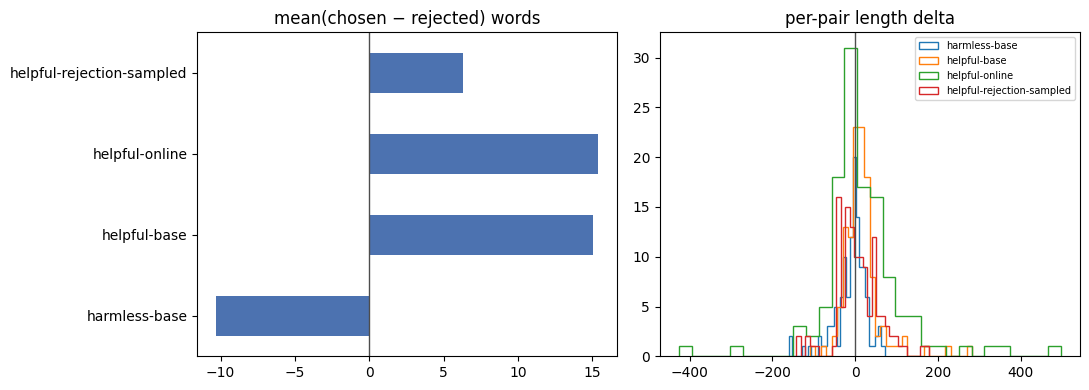


Sanitized structural preview (user text is not printed):
{'source': 'helpful-base', 'prompt_turns': 3, 'chosen_words': 56, 'rejected_words': 6}
{'source': 'helpful-base', 'prompt_turns': 9, 'chosen_words': 3, 'rejected_words': 1}
{'source': 'helpful-base', 'prompt_turns': 3, 'chosen_words': 39, 'rejected_words': 10}

Training a lexical diagnostic to detect easy preference shortcuts...
Lexical diagnostic (observed) accuracy: 0.496
Lexical diagnostic (observed) ROC-AUC:  0.509
              precision    recall  f1-score   support

    rejected      0.495     0.451     0.472       237
      chosen      0.496     0.540     0.517       237

    accuracy                          0.496       474
   macro avg      0.496     0.496     0.495       474
weighted avg      0.496     0.496     0.495       474

Lexical diagnostic (permuted labels) accuracy: 0.487
Lexical diagnostic (permuted labels) ROC-AUC:  0.485
Chance baseline from permuted labels: AUC 0.485
-> observed AUC is within permutation 

Map:   0%|          | 0/475 [00:00<?, ? examples/s]

Filter:   0%|          | 0/475 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Filter:   0%|          | 0/120 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/90 [00:00<?, ? examples/s]

Dropping fully truncated examples from eval dataset:   0%|          | 0/90 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


  DPOTrainer built OK

Training for 30 steps on cpu (effective batch 8)...


Step,Training Loss


In [ ]:
@torch.no_grad()
def completion_logprob(policy, messages_prompt, message_completion, use_ref=False):
    prompt_txt = tok.apply_chat_template(messages_prompt, tokenize=False, add_generation_prompt=True)
    full_txt = prompt_txt + message_completion["content"] + tok.eos_token
    p_ids = tok(prompt_txt, add_special_tokens=False, return_tensors="pt")["input_ids"]
    f_ids = tok(full_txt, add_special_tokens=False, return_tensors="pt",
                truncation=True, max_length=MAX_LENGTH)["input_ids"].to(policy.device)
    start = min(p_ids.shape[1], f_ids.shape[1] - 1)

    ctx = policy.disable_adapter() if (use_ref and hasattr(policy, "disable_adapter")) else None
    if ctx is not None:
        with ctx:
            logits = policy(f_ids).logits
    else:
        logits = policy(f_ids).logits

    logprobs = torch.log_softmax(logits[:, :-1].float(), dim=-1)
    targets = f_ids[:, 1:]
    picked = logprobs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return picked[:, start:].sum().item()

def per_source_reward_accuracy(n=N_REWARD_EVAL):
    policy = trainer.model
    policy.eval()
    if not hasattr(policy, "disable_adapter") and getattr(trainer, "ref_model", None) is None:
        print("  no reference model reachable; skipping per-source analysis")
        return None

    idx = rng.permutation(len(test_sources))[:min(n, len(test_sources))]
    rows = []
    for i in idx:
        i = int(i)
        rc = completion_logprob(policy, test_prompts[i], test_chosen[i][0])
        rr = completion_logprob(policy, test_prompts[i], test_rejected[i][0])
        refc = completion_logprob(policy, test_prompts[i], test_chosen[i][0], use_ref=True)
        refr = completion_logprob(policy, test_prompts[i], test_rejected[i][0], use_ref=True)
        rows.append({
            "source": test_sources[i],
            "margin": BETA * ((rc - refc) - (rr - refr)),
            "correct": BETA * ((rc - refc) - (rr - refr)) > 0,
            "len_delta": len(test_chosen[i][0]["content"].split())
                         - len(test_rejected[i][0]["content"].split()),
        })
    df = pd.DataFrame(rows)
    out = df.groupby("source").agg(
        n=("correct", "size"),
        reward_accuracy=("correct", "mean"),
        mean_margin=("margin", "mean"),
        mean_len_delta=("len_delta", "mean"),
    ).round(3)
    print(out.to_string())

    longer_wins = (df["correct"] == (df["len_delta"] > 0)).mean()
    print(f"\n  agreement between 'model prefers chosen' and 'chosen is longer': {longer_wins:.3f}")
    print("  (near 0.5 = no length shortcut; near 1.0 = the policy is mostly ranking by length)")
    return out

print(f"\nPer-source reward accuracy on {N_REWARD_EVAL} held-out pairs:")
try:
    per_source = per_source_reward_accuracy()
except Exception as exc:
    print(f"  skipped: {type(exc).__name__}: {exc}")
    per_source = None

def generate(messages, max_new_tokens=96):
    text = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    enc = tok(text, return_tensors="pt").to(trainer.model.device)
    with torch.no_grad():
        out = trainer.model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                                     pad_token_id=tok.pad_token_id)
    return tok.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

probes = [
    [{"role": "user", "content": "My laptop fan is suddenly very loud. What should I check first?"}],
    [{"role": "user", "content": "Explain in two sentences why DPO does not need a separate reward model."}],
]
print("\nSample generations from the tuned policy:")
for p in probes:
    print(f"\n  user      : {p[0]['content']}")
    print(f"  assistant : {generate(p)}")

trainer.save_model(OUTPUT_DIR)
tok.save_pretrained(OUTPUT_DIR)
print(f"\nSaved to {OUTPUT_DIR}")

print("""
Reading the results
  * At MAX_STEPS=30 on CPU this is a smoke test, not a trained model. Reward accuracy
    near 0.5 is the expected outcome; raise MAX_STEPS on a GPU before concluding anything.
  * The number to watch is the per-source table, not the aggregate. If harmless-base
    reward accuracy drops while the helpful subsets rise, the policy is learning the
    length asymmetry visible in the section 5 audit rather than the intended preference.
  * If a TRL call fails after an upgrade, the environment report at the top names which
    class accepts which argument in your build; extend `wanted_args` from that list.
""")